# Goodness of Model / Fit / Prediction in Linear Regression

# R²

In linear regression, goodness of fit answers: “How closely does the fitted line match the actual data points?”

R² is the most common metric used to quantify this.

R² measures how much of the variation in the dependent variable (y) is explained by your regression model.

$$R^2 = \frac{\text{Amount of variance in the data explained by the model}}{\text{Total variance in the data}}$$

$$ R^2 = \frac{SS_{reg}}{SS_{tot}}$$

$$ R^2 = 1 - \frac{SS_{err}}{SS_{tot}}$$

Where,
- $SS_{reg} = \sum{(\hat{y} - \bar{y})}^2$ → Amount of variance in the original data explained / captured by the model
- $SS_{err} = \sum{(y_i - \hat{y_i})}^2$ → Amount of variance in the original data not explained by the model
- $SS_{tot} = \sum{(y_i - \bar{y})}^2$ →  Total variance in the original data

Interpretation:
- R² $\approx$ 1 : Good fit
- R² $\approx$ 0 : Poor fit
- R² < 0 : Very bad fit (Model predictions worse than just predicting mean)

Note:
- High R² doesn’t guarantee better model always. It can lead to overfitting (especially with higher-degree models).
- Low R² isn’t always bad. Real-world noisy data often has lower R².

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# set the random number generator seed for reproducibility
rng = np.random.default_rng(42)

In [2]:
# Temperature in Farenheit
temperature = np.arange(-340, 100, 20)

# Co-efficient of Thermal Expansion
alpha = np.array([2.450, 2.760, 3.070, 3.330, 3.580, 3.830, 4.080, 4.300, 4.520, \
              4.720, 4.910, 5.090, 5.280, 5.430, 5.580, 5.720, 5.860, 6.000, \
              6.120, 6.240, 6.360, 6.470])*1.0e-6

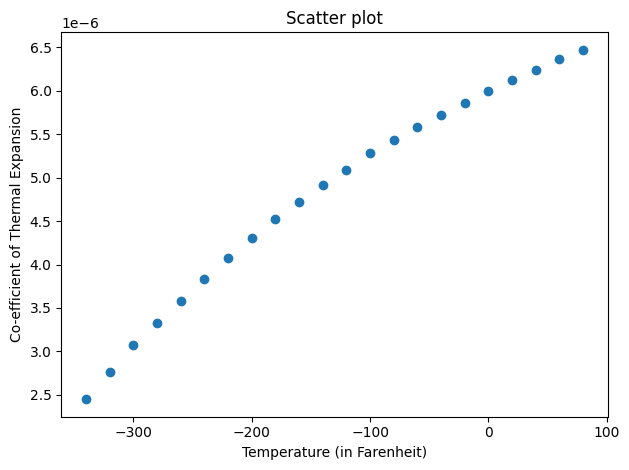

In [3]:
plt.scatter(temperature, alpha)
plt.xlabel("Temperature (in Farenheit)")
plt.ylabel("Co-efficient of Thermal Expansion")
plt.title("Scatter plot")

plt.tight_layout()
plt.show()

In [4]:
def create_polynomial_features(x, degree):
    return np.vstack([x**i for i in range(degree + 1)]).T

In [5]:
# Normalize inputs & outputs
x = (temperature - np.mean(temperature)) / np.std(temperature)
y = (alpha - np.mean(alpha)) / np.std(alpha)

In [6]:
class Model():
    
    def __init__(self, X, y, x_mean, x_std, y_mean, y_std, x_original):
        self.X = X
        self.y = y
        self.m, self.n = self.X.shape
        self.w = rng.random(self.n)
        self.cost_history = []

        # store scaling info
        self.x_mean = x_mean
        self.x_std = x_std
        self.y_mean = y_mean
        self.y_std = y_std
        self.x_original = x_original

    def gradient_descent(self, eta=0.1, eps=1e-6, max_iters=10000):
        cost_change = 1
        num_iters = 0

        while cost_change > eps and num_iters < max_iters:
            self.yhat = self.X @ self.w
            gradient = -(self.X.T @ (self.y - self.yhat)) / self.m
            self.w = self.w - eta * gradient
            cost = self.compute_cost()
            self.cost_history.append(cost)
            
            if len(self.cost_history) > 1:
                cost_change = np.abs(self.cost_history[-1] - self.cost_history[-2])
            
            num_iters += 1

        print("Weights:", self.w)
        print("Iterations:", num_iters)
        
        return self.w, self.cost_history, num_iters

    def compute_cost(self):
        return (0.5 / self.m) * np.sum((self.y - self.X @ self.w)**2)

    def fit(self, eta=0.1, eps=1e-6, max_iters=10000):
        return self.gradient_descent(eta, eps, max_iters)
    
    def plot(self):
        self.yhat = self.X @ self.w

        x_real = self.x_original
        yhat_real = self.yhat * self.y_std + self.y_mean
        y_real = self.y * self.y_std + self.y_mean
        
        idx = np.argsort(x_real)
    
        plt.figure(figsize=(8, 6))
        
        plt.subplot(211)
        plt.plot(x_real[idx], y_real[idx], 'bo', label="Original data")
        plt.plot(x_real[idx], yhat_real[idx], 'r-', label=f"{self.n-1}-degree Polynomial Fit")
        plt.legend()
        
        plt.subplot(212)
        plt.plot(self.cost_history, '-o')
        plt.xlabel("iterations")
        plt.ylabel("Cost")
        
        plt.tight_layout()
        plt.show()

    def predict(self, x_new):
        x_new_norm = (x_new - self.x_mean) / self.x_std
        X_new = create_polynomial_features(x_new_norm, self.n-1)
        
        yhat_norm = X_new @ self.w
        yhat_real = yhat_norm * self.y_std + self.y_mean
        
        return yhat_real

    def score(self):
        yhat = self.X @ self.w
        
        ss_err = np.sum((self.y - yhat)**2)
        ss_tot = np.sum((self.y - np.mean(self.y))**2)
        
        r2 = 1 - (ss_err / ss_tot)
        return r2

Weights: [ 0.14452717  0.95423215 -0.1130283   0.01932459 -0.01813214]
Iterations: 476
r2 score=  0.9997701302110897


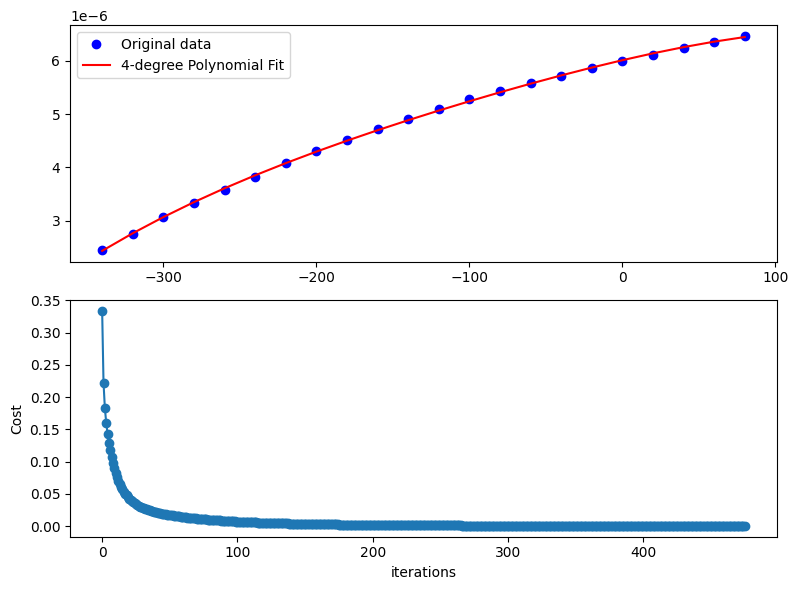

Predictions for [0, 50, 100] =  [6.01393602e-06 6.31273315e-06 6.51708948e-06]


In [7]:
X = create_polynomial_features(x, degree=4)
model = Model(X, y, x_mean=np.mean(temperature), x_std=np.std(temperature), y_mean=np.mean(alpha), y_std=np.std(alpha), x_original=temperature)

w, cost_history, num_iters = model.fit(eta=0.1)
print("r2 score= ", model.score())
model.plot()

print("Predictions for [0, 50, 100] = ", model.predict(np.array([0, 50, 100])))

Weights: [ 3.88662997e+135  1.50576129e+152 -1.05138963e+136  3.41094990e+152
  2.08724140e+136  8.19233844e+152]
Iterations: 764
r2 score=  -inf


C:\Users\adeet\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\adeet\AppData\Local\Temp\ipykernel_14016\2680899904.py:29: RuntimeWarning: invalid value encountered in scalar subtract
  cost_change = np.abs(self.cost_history[-1] - self.cost_history[-2])


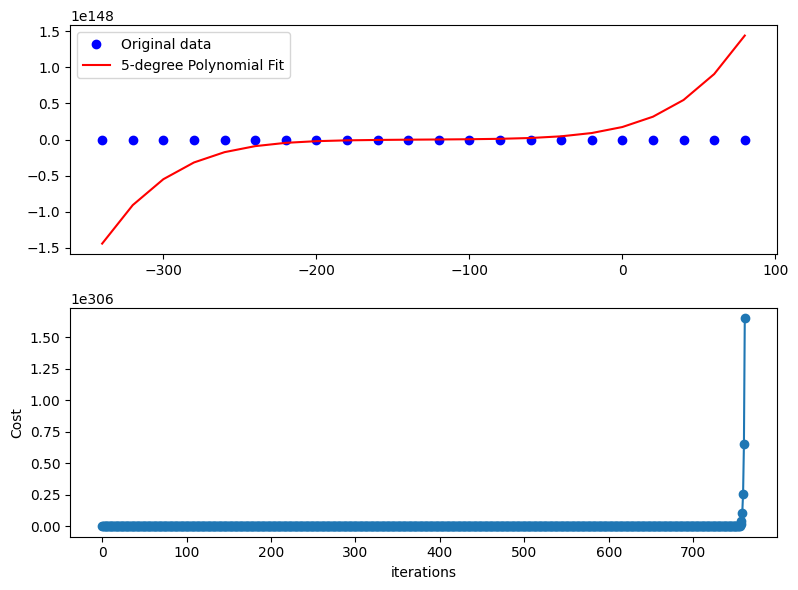

Predictions for [0, 50, 100] =  [1.74113864e+147 7.09729988e+147 2.20799013e+148]


In [8]:
X = create_polynomial_features(x, degree=5)
model = Model(X, y, x_mean=np.mean(temperature), x_std=np.std(temperature), y_mean=np.mean(alpha), y_std=np.std(alpha), x_original=temperature)

w, cost_history, num_iters = model.fit()
print("r2 score= ", model.score())
model.plot()

print("Predictions for [0, 50, 100] = ", model.predict(np.array([0, 50, 100])))

A higher-degree polynomial should be able to fit training data at least as well as a lower-degree one. But our result (5th degree blowing up) is actually a classic gradient descent instability issue, not a modeling limitation.

**Exploding values**
- Our 5-degree model output goes to ~1e148.
- Cost shoots to ~1e306
- This is not “bad fitting” — this is numerical explosion / divergence.
- Gradient descent is not converging.

**High-degree polynomial → unstable optimization**

When you increase degree

$$ \mathbf{x}, \mathbf{x²}, \mathbf{x³}, \mathbf{x⁴}, \mathbf{x⁵} $$

Even if x is normalized:
- powers like $x^5$ can still be large or highly correlated
- leads to:
    - ill-conditioned matrix
    - stteep gradients
    - unstable updates

**Learning rate too high**

You are using:
$$ \eta = 0.1 $$

For degree 4, it is OK

But for degree 5, it is TOO LARGE

## Fix : Reduced Learning Rate

### 4th degree polynomial model with $\eta = 0.01$

Weights: [ 0.1031427   0.93026065 -0.00310481  0.03096405 -0.05746349]
Iterations: 2181
eta =  0.01
r2 score=  0.9981255670085388


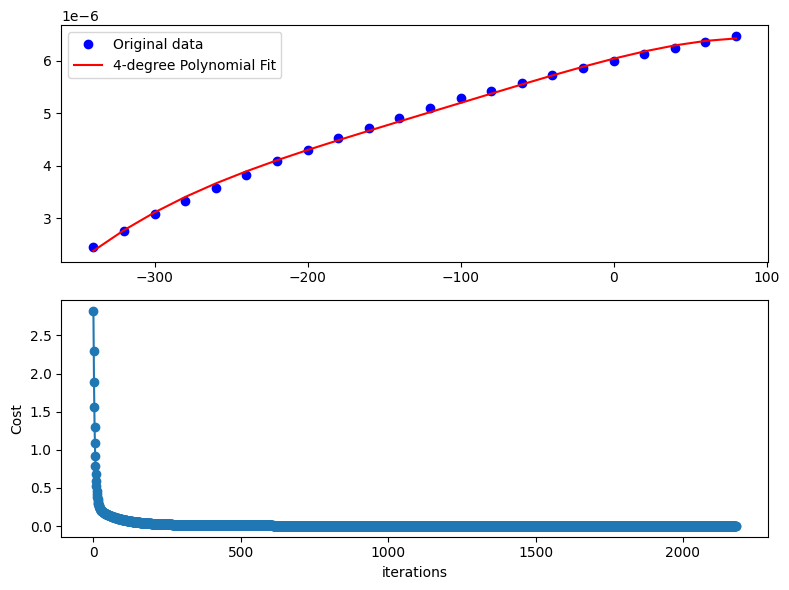

Predictions for [0, 50, 100] =  [6.03635967e-06 6.33653326e-06 6.42201533e-06]


In [9]:
eta = 0.01
X = create_polynomial_features(x, degree=4)
model = Model(X, y, x_mean=np.mean(temperature), x_std=np.std(temperature), y_mean=np.mean(alpha), y_std=np.std(alpha), x_original=temperature)

w, cost_history, num_iters = model.fit(eta)
print("eta = ", eta)
print("r2 score= ", model.score())
model.plot()

print("Predictions for [0, 50, 100] = ", model.predict(np.array([0, 50, 100])))

### 5th degree polynomial model with $\eta = 0.01$

Weights: [ 0.13516136  0.67687819 -0.08815163  0.40177018 -0.02703314 -0.10824238]
Iterations: 3474
eta =  0.01
r2 score=  0.995110218029297


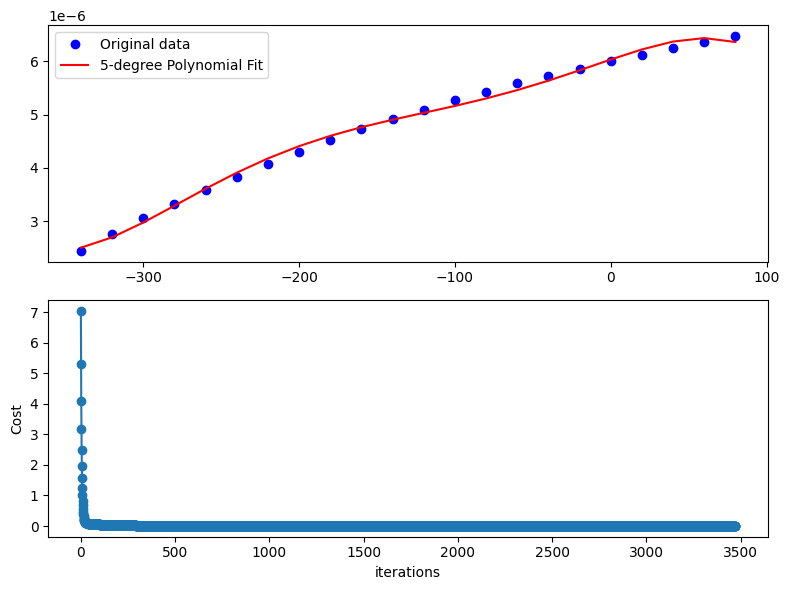

Predictions for [0, 50, 100] =  [6.02824923e-06 6.41044460e-06 6.07528144e-06]


In [10]:
eta = 0.01
X = create_polynomial_features(x, degree=5)
model = Model(X, y, x_mean=np.mean(temperature), x_std=np.std(temperature), y_mean=np.mean(alpha), y_std=np.std(alpha), x_original=temperature)

w, cost_history, num_iters = model.fit(eta)
print("eta = ", eta)
print("r2 score= ", model.score())
model.plot()

print("Predictions for [0, 50, 100] = ", model.predict(np.array([0, 50, 100])))

### 9th degree polynomial model with $\eta = 0.01$

Weights: [ 0.14979495  0.73862128 -0.08842548  0.36941165 -0.06816444 -0.16319395
  0.01582418  0.02301522]
Iterations: 2313
eta =  0.01
r2 score=  0.9981963014537398


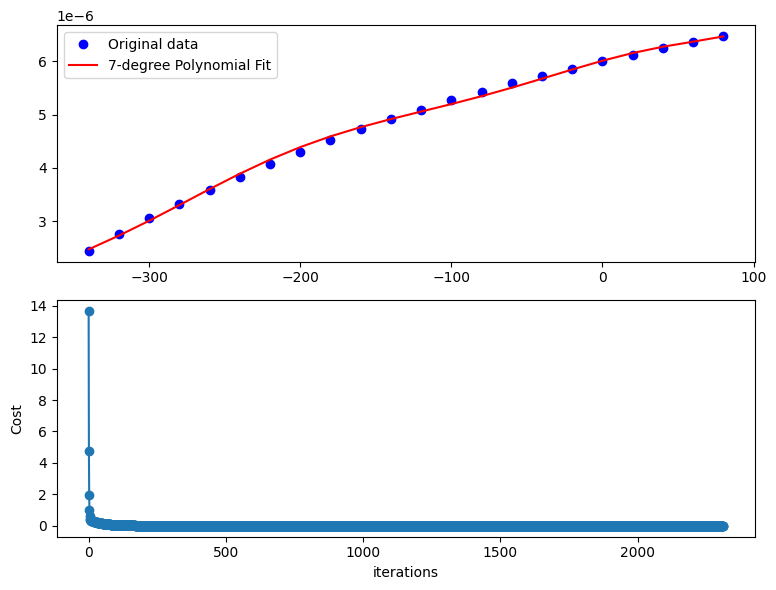

Predictions for [0, 50, 100] =  [6.00539979e-06 6.31660960e-06 6.62280768e-06]


In [15]:
eta = 0.01
X = create_polynomial_features(x, degree=7)
model = Model(X, y, x_mean=np.mean(temperature), x_std=np.std(temperature), y_mean=np.mean(alpha), y_std=np.std(alpha), x_original=temperature)

w, cost_history, num_iters = model.fit(eta)
print("eta = ", eta)
print("r2 score= ", model.score())
model.plot()

print("Predictions for [0, 50, 100] = ", model.predict(np.array([0, 50, 100])))